### This code is for plotting responder figures with quartiles 

Created by: Martina Hollearn        7/17/2024


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import ttest_ind
from scipy.stats import ttest_rel
from matplotlib.lines import Line2D
import os

def _broadcast_swarm_values(values, n, default):
    if values is None:
        return np.array([default] * n, dtype=object)
    if np.isscalar(values) or (isinstance(values, tuple) and len(values) in (3, 4)):
        return np.array([values] * n, dtype=object)
    arr = np.asarray(list(values), dtype=object)
    if arr.size != n:
        return np.array([values] * n, dtype=object)
    return arr

def _compute_swarm_offsets(y_values, max_width=0.22, min_y_gap=None):
    y = np.asarray(y_values, dtype=float)
    offsets = np.zeros(len(y), dtype=float)

    if len(y) <= 1:
        return offsets

    y_span = np.ptp(y)
    if min_y_gap is None:
        min_y_gap = max(y_span * 0.04, 0.03)

    step = max_width / 5.0 if max_width > 0 else 0.0
    order = np.argsort(y, kind='mergesort')
    placed = []
    candidates = [0.0]

    for level in range(1, 12):
        offset = level * step
        if offset > max_width + 1e-9:
            break
        candidates.extend([offset, -offset])

    for idx in order:
        yi = y[idx]
        chosen = 0.0

        for candidate in candidates:
            collision = any(
                abs(yi - prev_y) < min_y_gap and abs(candidate - prev_x) < step * 0.9
                for prev_y, prev_x in placed
            )
            if not collision:
                chosen = candidate
                break

        offsets[idx] = chosen
        placed.append((yi, chosen))

    return offsets

def swarm_scatter(ax, x_center, y_values, colors=None, markers=None, sizes=None,
                  max_width=0.22, min_y_gap=None, alpha=0.9, zorder=3):
    y = np.asarray(y_values, dtype=float)
    if len(y) == 0:
        return np.array([])

    colors = _broadcast_swarm_values(colors, len(y), 'black')
    markers = _broadcast_swarm_values(markers, len(y), 'o')
    sizes = np.asarray(_broadcast_swarm_values(sizes, len(y), 220), dtype=float)
    offsets = _compute_swarm_offsets(y, max_width=max_width, min_y_gap=min_y_gap)

    for marker in pd.unique(markers):
        idx = np.where(markers == marker)[0]
        ax.scatter(
            np.full(len(idx), x_center, dtype=float) + offsets[idx],
            y[idx],
            s=sizes[idx],
            c=colors[idx].tolist(),
            marker=marker,
            alpha=alpha,
            linewidths=0,
            zorder=zorder
        )

    return offsets

In [2]:
df = pd.read_csv('../AMMEBLAES_includedpts_firstsession_behavioral.csv')
print(df.columns)
stim_dprime_diff = df['avg_stim_dprime_diff']
nsubjects = len(df)
print(f"Number of subjects: {nsubjects}")

Index(['Study', 'Patient', 'Memory_delay', 'stim_hemisphere',
       'stim_trajectory', 'stim_outside_amyg', 'stim_DB', 'IED_freq',
       'IED_laterality', 'nostim', 'avg_stim', 'avg_stim_dprime_diff', 'FSIQ',
       'WMS-IV_VR_recog_raw', 'WMS-IV_VR_recog_score', 'RAVLT_delayedrecall',
       'ReyO_CF_delayedrecall', 'age', 'sex', 'Memory_Z', 'Memory',
       'dist_BLAtoHPC'],
      dtype='object')
Number of subjects: 54


### Connected dot plot for stim vs no stim comparisons

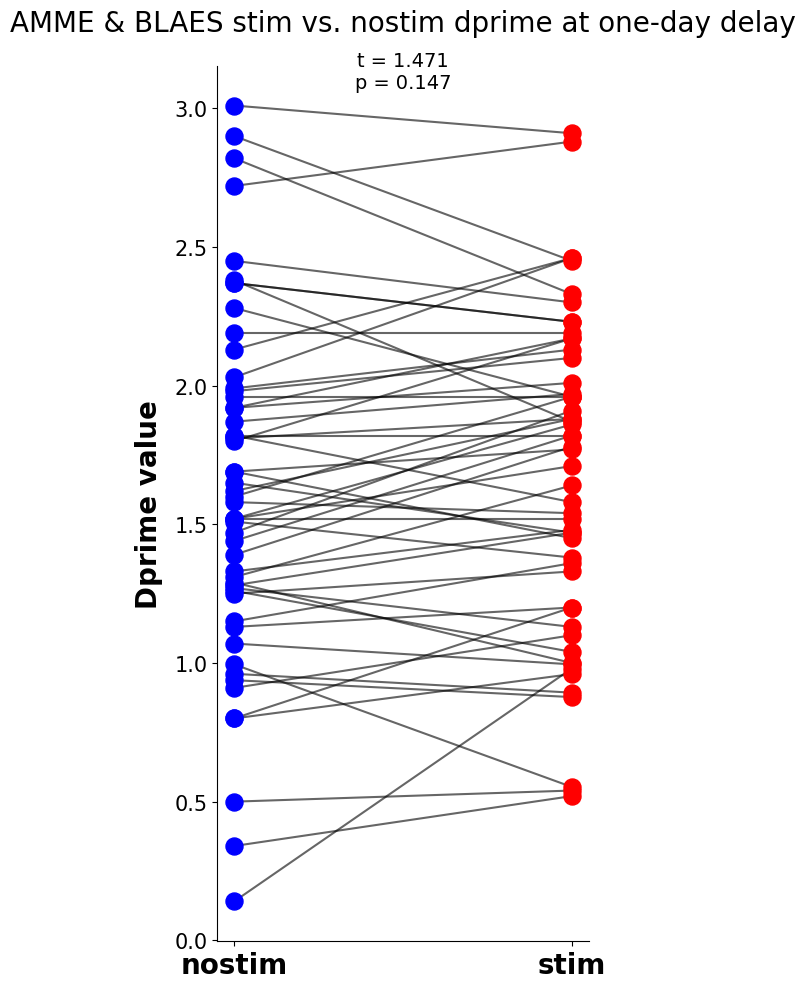

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

stim = df['avg_stim']
nostim = df['nostim']

# Paired t-test
t_stat, p_value = ttest_rel(stim, nostim)

# Colors
colors = {"stim": "red", "nostim": "blue"}

# Create figure
plt.figure(figsize=(5, 10))
ax = plt.gca()

# --- Draw connecting lines FIRST (flipped order) ---
for s, n in zip(stim, nostim):
    ax.plot(
        ["nostim", "stim"],   # 🔥 flipped order
        [n, s],
        color='black',
        linewidth=1.5,
        alpha=0.6,
        zorder=1
    )

# --- Draw points ON TOP (flipped positions) ---
ax.scatter(
    ["nostim"] * len(nostim),
    nostim,
    color=colors["nostim"],
    s=150,
    zorder=3
)

ax.scatter(
    ["stim"] * len(stim),
    stim,
    color=colors["stim"],
    s=150,
    zorder=3
)

# Labels
ax.set_ylabel("Dprime value", fontsize=20, fontweight='bold', labelpad=8)
ax.set_xlabel("")

# Title
ax.set_title(
    "AMME & BLAES stim vs. nostim dprime at one-day delay",
    fontsize=20,
    pad=25,
    fontweight='normal'
)

# Stats text
stats_text = f"t = {t_stat:.3f}\np = {p_value:.3f}"
ax.text(
    0.5, 0.97,
    stats_text,
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=14
)

# --- Explicit x-axis order + larger font ---
ax.set_xticks([0, 1])
ax.set_xticklabels(["nostim", "stim"], fontsize=20, fontweight='bold')

# Tick formatting
ax.tick_params(axis='y', labelsize=15)

# Clean spines
for pos in ['right', 'top']:
    ax.spines[pos].set_visible(False)

# Layout
plt.tight_layout()

# Save and show
plt.savefig('AMME_BLAES_Stim_NoStim_connected_dotplot.png', dpi=300)
plt.show()

### Plotting without hue

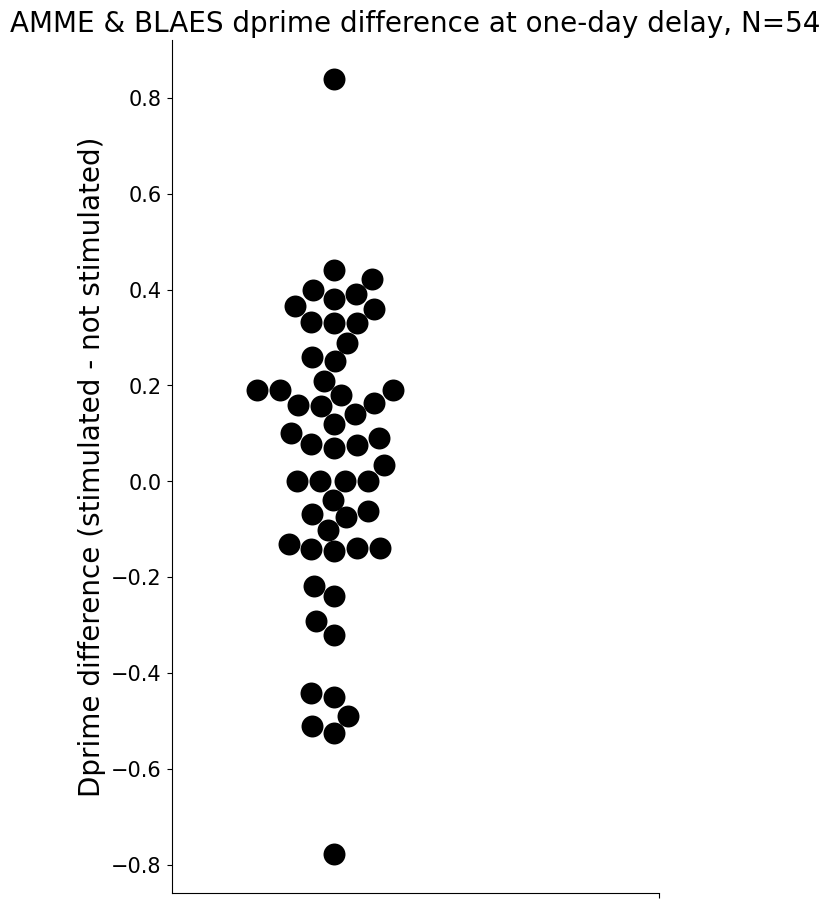

In [4]:
# Scatter plot with seaborn
ax1 = sns.catplot(x="Memory_delay", y='avg_stim_dprime_diff', 
                  data=df, s=250, kind='swarm', color='black')

# Format figure appearance
for pos in ['right', 'top']:
    plt.gca().spines[pos].set_visible(False)

# Set axis labels and ticks fontsize
plt.ylabel("Dprime difference (stimulated - not stimulated)", fontsize=20)
plt.xlabel('')
plt.xticks('')
plt.yticks(fontsize=15)
plt.title("AMME & BLAES dprime difference at one-day delay, N={}".format(nsubjects), fontsize=20)

# Adjust layout manually to respect figure size
plt.gcf().set_size_inches(6, 10)


# Show the plot
plt.savefig('AMMEBLAES_dprime_diff_swarmplot.png', dpi=300)
plt.show()

### Responder status in quartile plot

median= 0.076472 lowerQ= -0.13675 upperQ= 0.24004799999999998


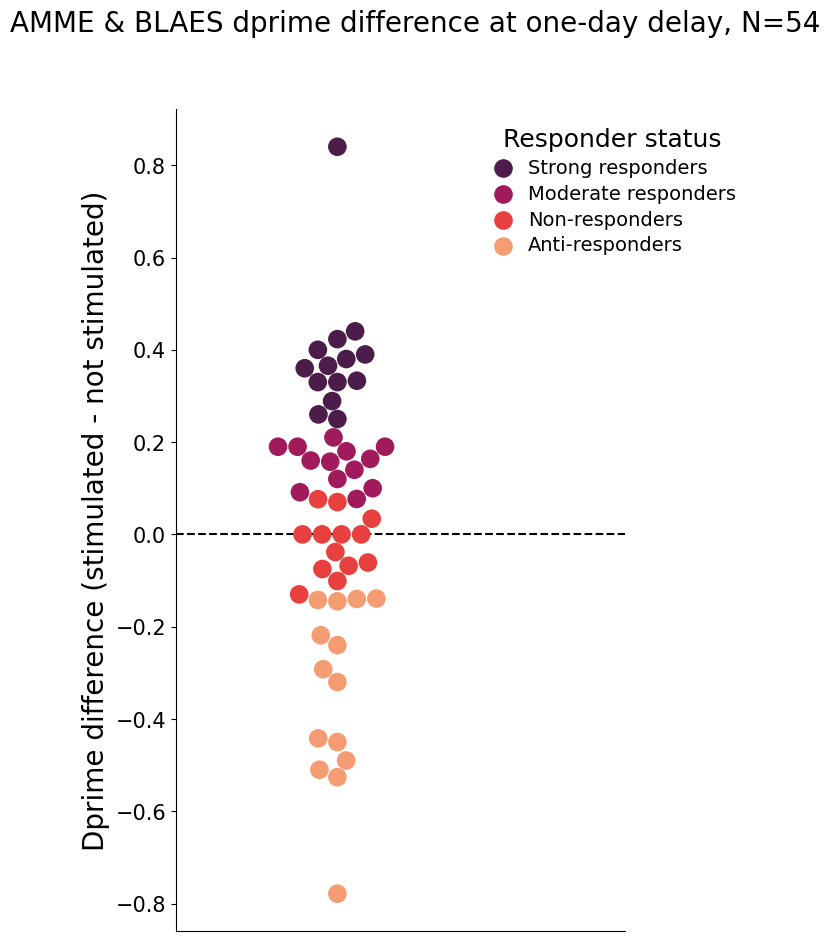

In [5]:
# Compute quartiles
median = stim_dprime_diff.median()
lower_quartile = np.percentile(stim_dprime_diff, 25)
upper_quartile = np.percentile(stim_dprime_diff, 75)

print("median=", median, "lowerQ=", lower_quartile, "upperQ=", upper_quartile)

# Assign quartile group with meaningful labels
def assign_group(value):
    if value <= lower_quartile:
        return 'Anti-responders'
    elif value <= median:
        return 'Non-responders'
    elif value <= upper_quartile:
        return 'Moderate responders'
    else:
        return 'Strong responders'

df['quartile'] = df['avg_stim_dprime_diff'].apply(assign_group)

# Desired legend order
hue_order = [
    'Strong responders',
    'Moderate responders',
    'Non-responders',
    'Anti-responders'
]

# Export responder status and use a fixed palette shared with the neural plots
responder_csv = os.path.join('outputs', 'csvs', 'AMMEBLAES_responder_status.csv')
os.makedirs(os.path.dirname(responder_csv), exist_ok=True)
responder_df = df[['Patient', 'avg_stim_dprime_diff', 'quartile']].rename(columns={'quartile': 'Responder status'})
responder_df = responder_df.sort_values('Patient').reset_index(drop=True)
responder_df.to_csv(responder_csv, index=False)
print(f"Saved responder status CSV to {responder_csv}")

palette = {
    'Strong responders': '#5B1A78',
    'Moderate responders': '#B21D6B',
    'Non-responders': '#F04646',
    'Anti-responders': '#F79B62',
}

# Create swarm plot
ax1 = sns.catplot(
    x="Memory_delay",
    y="avg_stim_dprime_diff",
    hue="quartile",
    hue_order=hue_order,
    data=df,
    kind="swarm",
    s=180,
    palette=palette,
    height=10,
    aspect=0.55
)

# Work on the actual axis
ax = ax1.ax

# Remove top and right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Add dashed horizontal line at y=0
ax.axhline(0, linestyle='--', color='black', linewidth=1.5, zorder=0)

# Labels and title
ax.set_ylabel("Dprime difference (stimulated - not stimulated)", fontsize=20)
ax.set_xlabel("")
ax.set_title("")
ax1.fig.suptitle(
    "AMME & BLAES dprime difference at one-day delay, N={}".format(nsubjects),
    fontsize=20
)

# Remove the x tick label "1"
ax.set_xticks([])

# Move the swarm closer to the y-axis by tightening x limits
# With only one x category, seaborn centers it at x=0; narrowing limits reduces empty side space
ax.set_xlim(-0.18, 0.32)

# Tick formatting
ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', labelsize=15, length=0)

# Adjust figure spacing
ax1.fig.subplots_adjust(left=0.18, right=0.78, top=0.88)

# Legend styling
leg = ax1._legend
leg.set_bbox_to_anchor((1, 0.75))
leg.set_frame_on(False)

for text in leg.get_texts():
    text.set_fontsize(14)

leg.set_title("Responder status", prop={'size': 18})

# Save and show
figure_path = os.path.join('outputs', 'behavioral', 'AMMEBLAES_responder_status_swarmplot.png')
os.makedirs(os.path.dirname(figure_path), exist_ok=True)
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()

### Sex differences 

Welch's t = 2.780840173975862 p = 0.008069216219313257


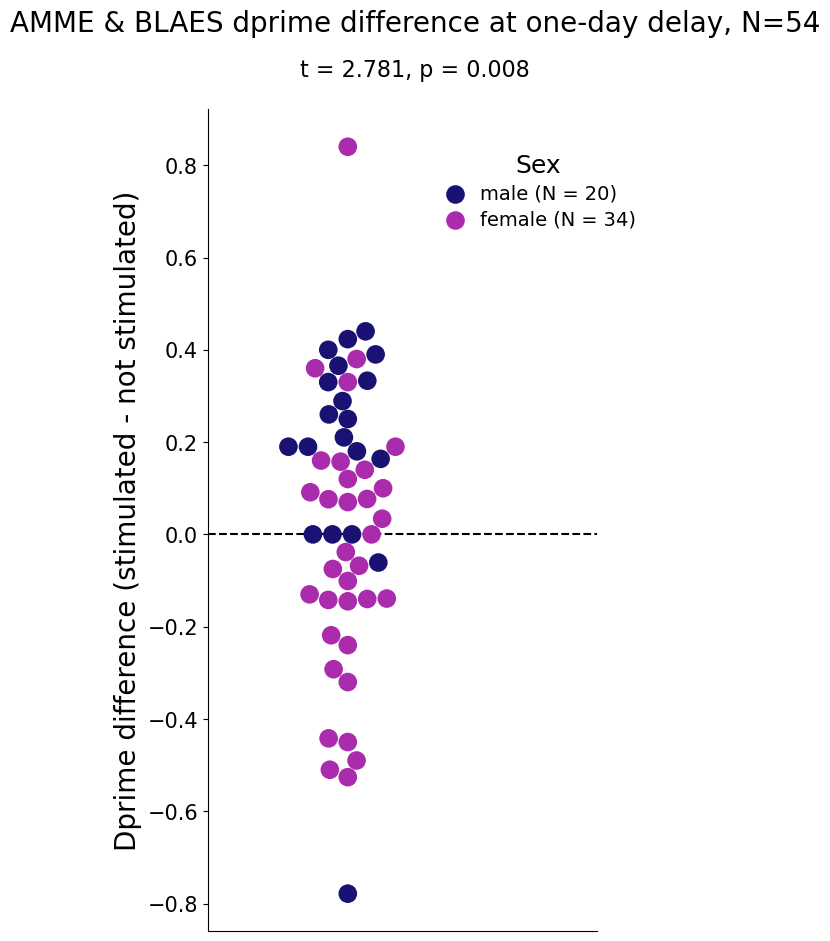

In [6]:
# Split data
male = df[df['sex'] == 'male']['avg_stim_dprime_diff']
female = df[df['sex'] == 'female']['avg_stim_dprime_diff']

# Welch's t-test
t_stat, p_val = ttest_ind(male, female, equal_var=False)

print("Welch's t =", t_stat, "p =", p_val)

# Format stats text
stats_text = f"t = {t_stat:.3f}, p = {p_val:.3f}"

# Sample sizes
n_male = len(male)
n_female = len(female)

# Define order + labels WITH N
hue_order = ['male', 'female']
legend_labels = {
    'male': f"male (N = {n_male})",
    'female': f"female (N = {n_female})"
}

# Define colors
palette = {
    'male': "#191273",    # indigo
    'female': "#AA2CAC"   # magenta
}

# Create swarm plot
ax1 = sns.catplot(
    x="Memory_delay",
    y="avg_stim_dprime_diff",
    hue="sex",
    hue_order=hue_order,
    data=df,
    kind="swarm",
    s=180,
    palette=palette,
    height=10,
    aspect=0.55
)

ax = ax1.ax

# Remove top/right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Horizontal line at 0
ax.axhline(0, linestyle='--', color='black', linewidth=1.5, zorder=0)

# Labels + title
ax.set_ylabel("Dprime difference (stimulated - not stimulated)", fontsize=20)
ax.set_xlabel("")
ax.set_title("")

ax1.fig.suptitle(
    "AMME & BLAES dprime difference at one-day delay, N={}".format(len(df)),
    fontsize=20
)

# 👉 Add t-test text UNDER title (centered)
ax1.fig.text(
    0.5, 0.92, stats_text,
    ha='center', va='center',
    fontsize=16
)

# Remove x tick label
ax.set_xticks([])

# Tighten x spacing
ax.set_xlim(-0.18, 0.32)

# Tick formatting
ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', length=0)

# Adjust layout
ax1.fig.subplots_adjust(left=0.18, right=0.78, top=0.88)

# Legend styling
leg = ax1._legend
leg.set_bbox_to_anchor((1, 0.75))
leg.set_frame_on(False)

# 👉 Update legend labels with N
for t, label in zip(leg.texts, hue_order):
    t.set_text(legend_labels[label])
    t.set_fontsize(14)

leg.set_title("Sex", prop={'size': 18})

# Save + show
plt.savefig('AMMEBLAES_sex_swarmplot_stats.png', dpi=300, bbox_inches='tight')
plt.show()

### Age differences

Age mean = 33.94
Age median = 33.00
Age mode = [22, 23, 24, 38, 40]
Age std = 11.11
Age min = 17.00
Age max = 60.00
Age range = 43.00
Lower boundary = 28.39
Upper boundary = 39.50


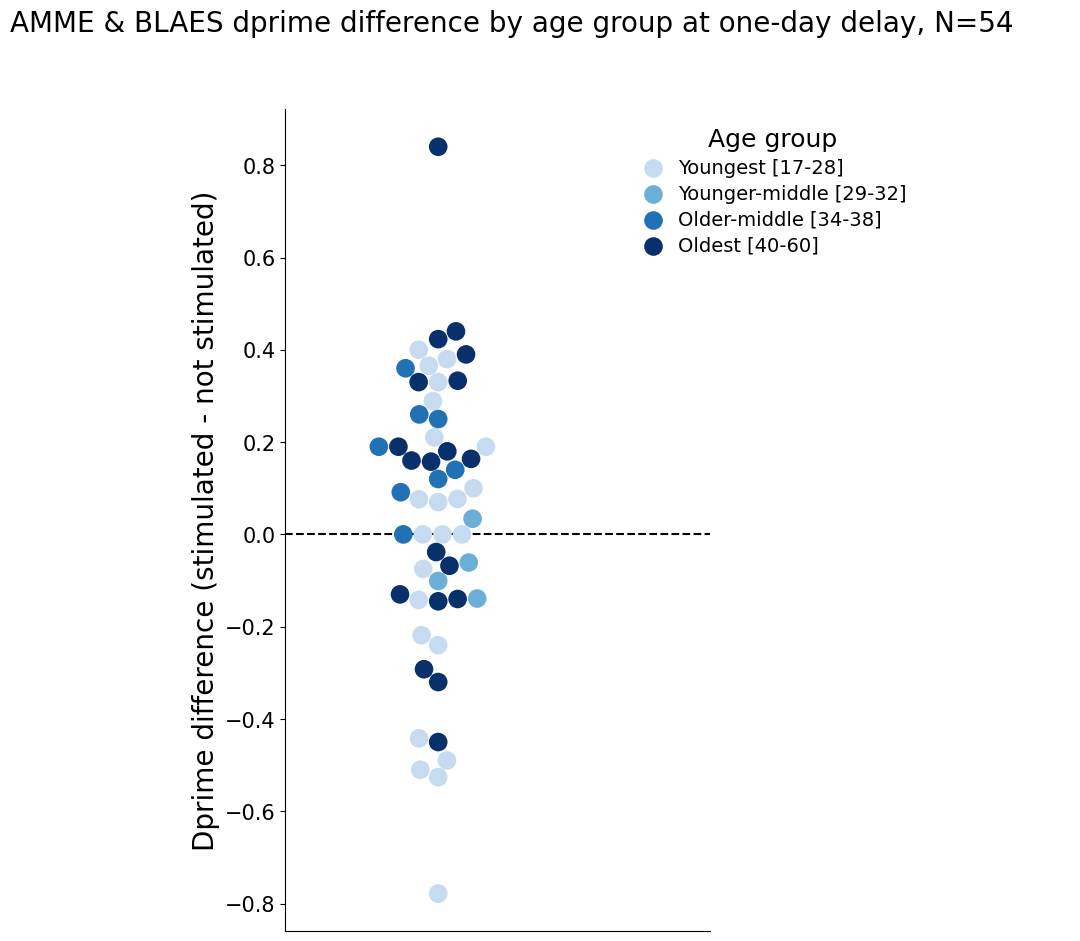

In [7]:
# Make sure age is numeric
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Drop missing ages for summary stats
age_clean = df['age'].dropna()

# Compute age distribution statistics
age_mean = age_clean.mean()
age_median = age_clean.median()
age_mode = age_clean.mode()
age_std = age_clean.std()
age_min = age_clean.min()
age_max = age_clean.max()
age_range = age_max - age_min

print(f"Age mean = {age_mean:.2f}")
print(f"Age median = {age_median:.2f}")
print(f"Age mode = {list(age_mode.values)}")
print(f"Age std = {age_std:.2f}")
print(f"Age min = {age_min:.2f}")
print(f"Age max = {age_max:.2f}")
print(f"Age range = {age_range:.2f}")

# Create 4 age groups using the observed spread around the mean/std
lower_bound = age_mean - 0.5 * age_std
upper_bound = age_mean + 0.5 * age_std

print(f"Lower boundary = {lower_bound:.2f}")
print(f"Upper boundary = {upper_bound:.2f}")

def assign_age_group(age):
    if pd.isna(age):
        return np.nan
    elif age <= lower_bound:
        return 'Youngest'
    elif age <= age_mean:
        return 'Younger-middle'
    elif age <= upper_bound:
        return 'Older-middle'
    else:
        return 'Oldest'

df['age_group'] = df['age'].apply(assign_age_group)

# Desired legend order
hue_order = [
    'Youngest',
    'Younger-middle',
    'Older-middle',
    'Oldest'
]

# More distinct blue palette
palette = {
    'Youngest': '#C6DBEF',
    'Younger-middle': '#6BAED6',
    'Older-middle': '#2171B5',
    'Oldest': '#08306B'
}

# Compute age ranges for legend labels
age_ranges = (
    df.dropna(subset=['age_group', 'age'])
      .groupby('age_group')['age']
      .agg(['min', 'max'])
)

legend_labels = {}
for group in hue_order:
    if group in age_ranges.index:
        min_age = int(np.floor(age_ranges.loc[group, 'min']))
        max_age = int(np.ceil(age_ranges.loc[group, 'max']))
        legend_labels[group] = f"{group} [{min_age}-{max_age}]"
    else:
        legend_labels[group] = f"{group}"

# Create swarm plot
ax1 = sns.catplot(
    x="Memory_delay",
    y="avg_stim_dprime_diff",
    hue="age_group",
    hue_order=hue_order,
    data=df,
    kind="swarm",
    s=180,
    palette=palette,
    height=10,
    aspect=0.55
)

# Work on the actual axis
ax = ax1.ax

# Remove top and right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Add dashed horizontal line at y=0
ax.axhline(0, linestyle='--', color='black', linewidth=1.5, zorder=0)

# Labels and title
ax.set_ylabel("Dprime difference (stimulated - not stimulated)", fontsize=20)
ax.set_xlabel("")
ax.set_title("")
ax1.fig.suptitle(
    "AMME & BLAES dprime difference by age group at one-day delay, N={}".format(len(df)),
    fontsize=20
)

# Remove the x tick label
ax.set_xticks([])

# Move the swarm closer to the y-axis
ax.set_xlim(-0.18, 0.32)

# Tick formatting
ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', labelsize=15, length=0)

# Adjust figure spacing
ax1.fig.subplots_adjust(left=0.18, right=0.78, top=0.88)

# Legend styling
leg = ax1._legend
leg.set_bbox_to_anchor((1.3, 0.75))
leg.set_frame_on(False)

# Update legend labels with age ranges
for t, label in zip(leg.texts, hue_order):
    t.set_text(legend_labels[label])
    t.set_fontsize(14)

leg.set_title("Age group", prop={'size': 18})

# Save and show
plt.savefig('AMMEBLAES_age_group_swarmplot.png', dpi=300, bbox_inches='tight')
plt.show()

### Stim hemisphere differences

Welch's t = 1.7246613274457263 p = 0.09106871934240529


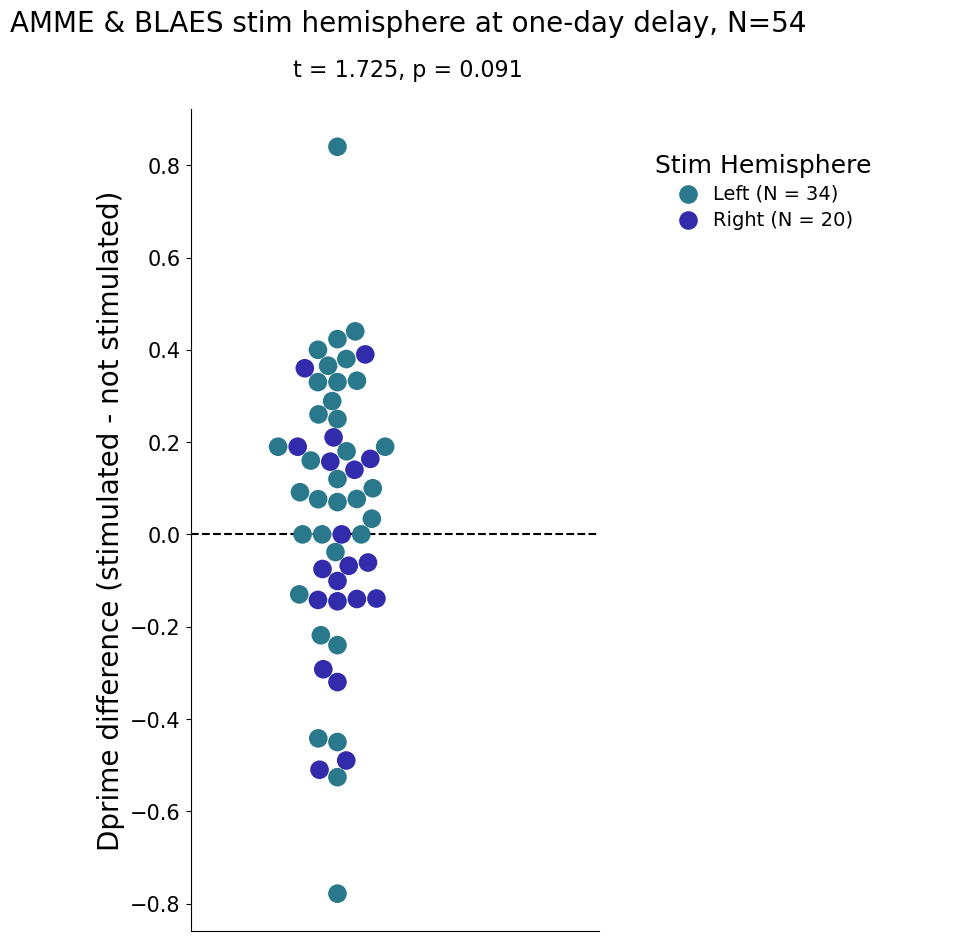

In [8]:
# Clean columns
df['stim_hemisphere'] = df['stim_hemisphere'].astype(str).str.strip().str.upper()

# Keep only valid rows
plot_df = df[
    df['stim_hemisphere'].isin(['L', 'R']) &
    df['avg_stim_dprime_diff'].notna()
].copy()

# Make x categorical so everything sits in one centered swarm
plot_df['delay_group'] = 'One-day delay'

# Split data for Welch's t-test
left = plot_df[plot_df['stim_hemisphere'] == 'L']['avg_stim_dprime_diff']
right = plot_df[plot_df['stim_hemisphere'] == 'R']['avg_stim_dprime_diff']

# Welch's t-test
t_stat, p_val = ttest_ind(left, right, equal_var=False)

print("Welch's t =", t_stat, "p =", p_val)

# Format stats text
stats_text = f"t = {t_stat:.3f}, p = {p_val:.3f}"

# Sample sizes
n_left = len(left)
n_right = len(right)

# Legend labels
legend_labels = {
    'L': f"Left (N = {n_left})",
    'R': f"Right (N = {n_right})"
}

# Colors
palette = {
    'L': "#2A788B",
    'R': "#322CAC"
}

# Create swarm plot
ax1 = sns.catplot(
    x="delay_group",
    y="avg_stim_dprime_diff",
    hue="stim_hemisphere",
    hue_order=['L', 'R'],
    data=plot_df,
    kind="swarm",
    s=180,
    palette=palette,
    height=10,
    aspect=0.55
)

ax = ax1.ax

# Remove top/right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Horizontal line at 0
ax.axhline(0, linestyle='--', color='black', linewidth=1.5, zorder=0)

# Labels + title
ax.set_ylabel("Dprime difference (stimulated - not stimulated)", fontsize=20)
ax.set_xlabel("")
ax.set_title("")

ax1.fig.suptitle(
    "AMME & BLAES stim hemisphere at one-day delay, N={}".format(len(plot_df)),
    fontsize=20
)

# Add t-test text under title
ax1.fig.text(
    0.5, 0.92, stats_text,
    ha='center', va='center',
    fontsize=16
)

# Remove x tick label
ax.set_xticks([])

# Match your single-column swarm layout
ax.set_xlim(-0.18, 0.32)

# Tick formatting
ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', length=0)

# Adjust layout
ax1.fig.subplots_adjust(left=0.18, right=0.78, top=0.88)

# Legend styling
leg = ax1._legend
leg.set_bbox_to_anchor((1.3, 0.75))
leg.set_frame_on(False)

# Update legend labels with N
for t, label in zip(leg.texts, ['L', 'R']):
    t.set_text(legend_labels[label])
    t.set_fontsize(14)

leg.set_title("Stim Hemisphere", prop={'size': 18})

# Save + show
plt.savefig('AMMEBLAES_hemisphere_swarmplot_stats.png', dpi=300, bbox_inches='tight')
plt.show()

### Stim amplitude

Welch's t = 1.4407243408110315 p = 0.16248338628607767


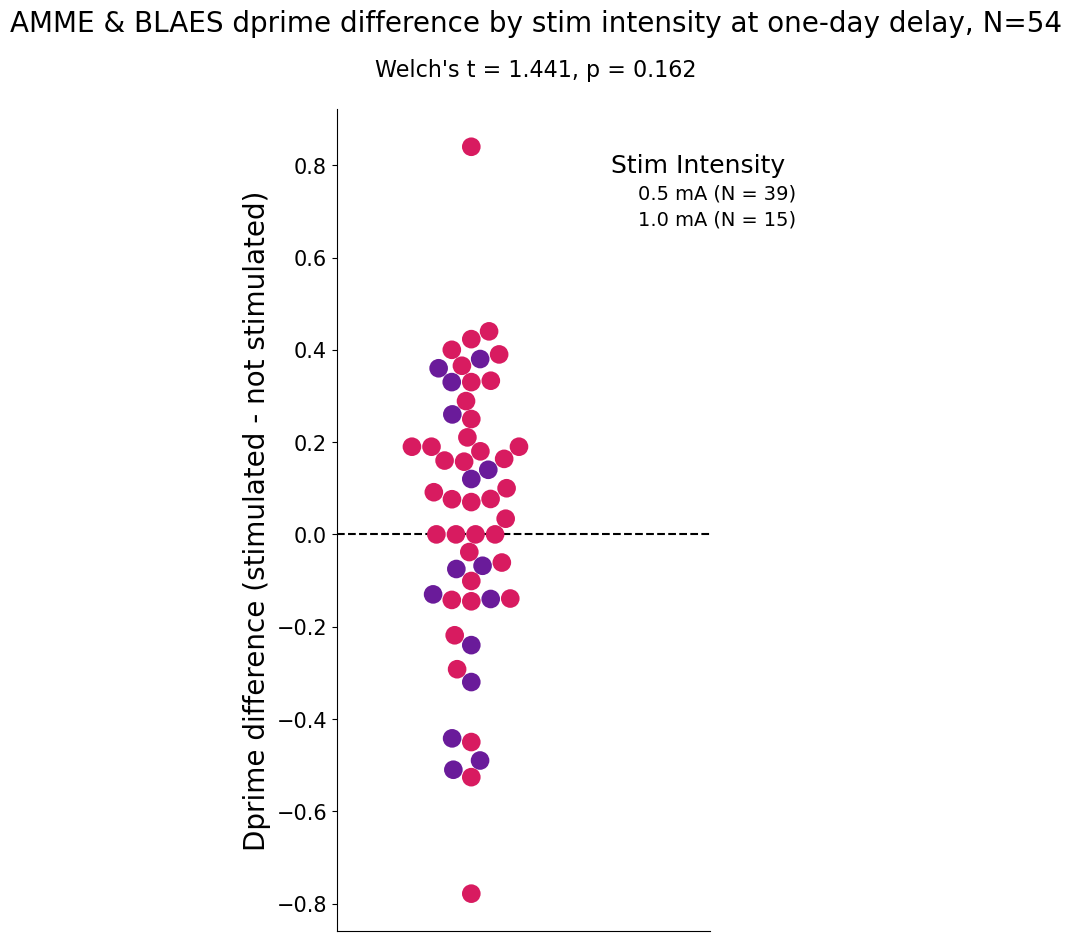

In [11]:
# Clean columns
df['stim_DB'] = pd.to_numeric(df['stim_DB'], errors='coerce')

# Keep only valid rows
plot_df = df[
    df['stim_DB'].isin([0.5, 1.0]) &
    df['avg_stim_dprime_diff'].notna()
].copy()

# Make x categorical so everything sits in one centered swarm
plot_df['delay_group'] = 'One-day delay'

# Split data for Welch's t-test (0.5 vs 1.0 mA)
low = plot_df[plot_df['stim_DB'] == 0.5]['avg_stim_dprime_diff']
high = plot_df[plot_df['stim_DB'] == 1.0]['avg_stim_dprime_diff']

t_stat, p_val = ttest_ind(low, high, equal_var=False)

print("Welch's t =", t_stat, "p =", p_val)

# Format stats text
stats_text = f"Welch's t = {t_stat:.3f}, p = {p_val:.3f}"

# Sample sizes
n_low = len(low)
n_high = len(high)

# Legend labels
legend_labels = {
    0.5: f"0.5 mA (N = {n_low})",
    1.0: f"1.0 mA (N = {n_high})"
}

# Magenta + purple palette
palette = {
    0.5: "#D81B60",   # magenta
    1.0: "#6A1B9A"    # purple
}

# Create swarm plot
ax1 = sns.catplot(
    x="delay_group",
    y="avg_stim_dprime_diff",
    hue="stim_DB",
    hue_order=[0.5, 1.0],
    data=plot_df,
    kind="swarm",
    s=180,
    palette=palette,
    height=10,
    aspect=0.55
)

ax = ax1.ax

# Remove top/right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Horizontal line at 0
ax.axhline(0, linestyle='--', color='black', linewidth=1.5, zorder=0)

# Labels + title
ax.set_ylabel("Dprime difference (stimulated - not stimulated)", fontsize=20)
ax.set_xlabel("")
ax.set_title("")

ax1.fig.suptitle(
    "AMME & BLAES dprime difference by stim intensity at one-day delay, N={}".format(len(plot_df)),
    fontsize=20
)

# Add t-test text under title
ax1.fig.text(
    0.5, 0.92, stats_text,
    ha='center', va='center',
    fontsize=16
)

# Remove x tick label
ax.set_xticks([])

# Match single-column swarm layout
ax.set_xlim(-0.18, 0.32)

# Tick formatting
ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', length=0)

# Adjust layout
ax1.fig.subplots_adjust(left=0.18, right=0.78, top=0.88)

# Legend styling
leg = ax1._legend
leg.set_bbox_to_anchor((1.3, 0.75))
leg.set_frame_on(False)

# Update legend labels with N
for t, val in zip(leg.texts, [0.5, 1.0]):
    t.set_text(legend_labels[val])
    t.set_fontsize(14)

leg.set_title("Stim Intensity", prop={'size': 18})

# Save + show
plt.savefig('AMMEBLAES_stim_intensity_swarmplot.png', dpi=300, bbox_inches='tight')
plt.show()

### Stim outside amygdala

Welch's t = 2.7799066365970075 p = 0.013278781367975742


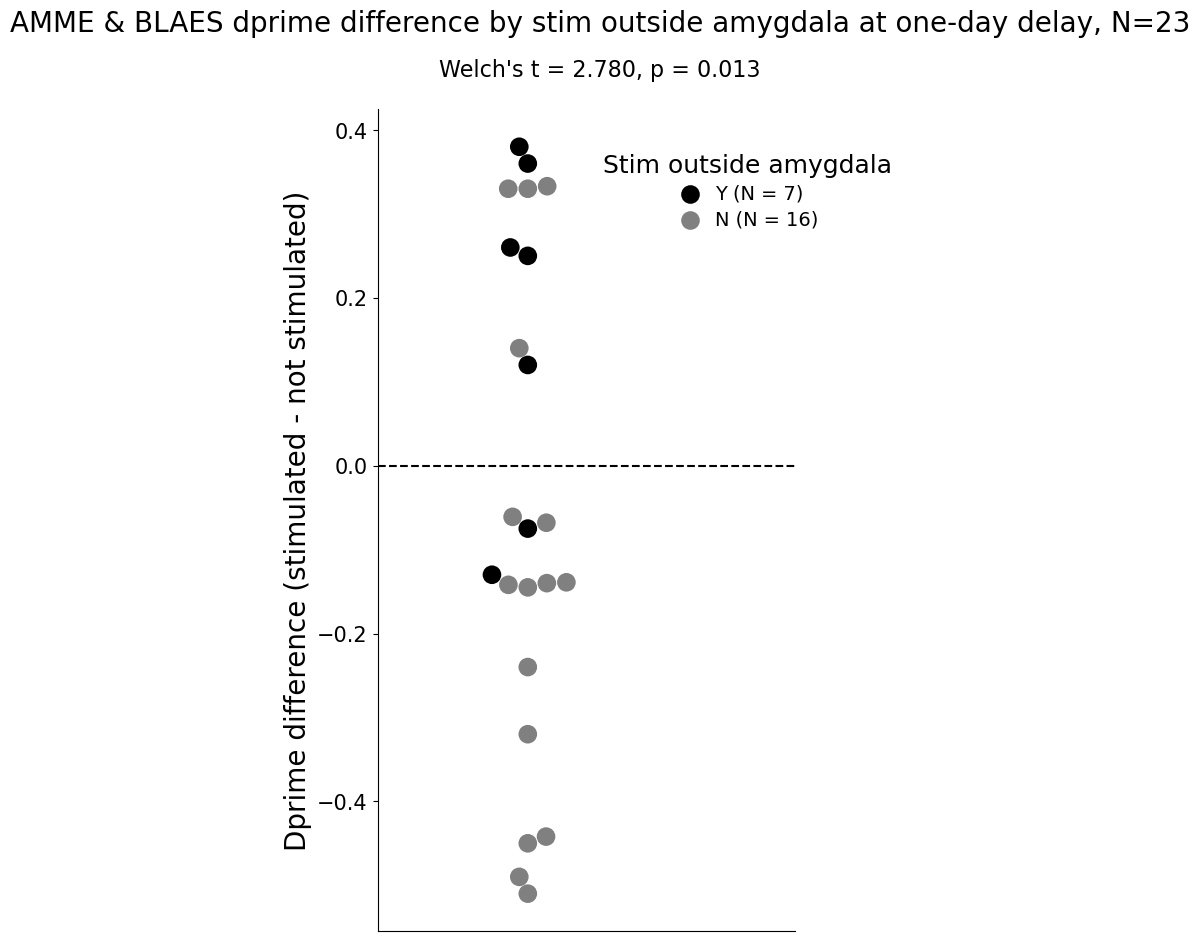

In [12]:
# Clean columns
df['stim_outside_amyg'] = df['stim_outside_amyg'].astype(str).str.strip().str.upper()

# Keep only valid rows
plot_df = df[
    df['stim_outside_amyg'].isin(['Y', 'N']) &
    df['avg_stim_dprime_diff'].notna()
].copy()

# Make x categorical so everything sits in one centered swarm
plot_df['delay_group'] = 'One-day delay'

# Split data for Welch's t-test (Y vs N)
outside_yes = plot_df[plot_df['stim_outside_amyg'] == 'Y']['avg_stim_dprime_diff']
outside_no = plot_df[plot_df['stim_outside_amyg'] == 'N']['avg_stim_dprime_diff']

t_stat, p_val = ttest_ind(outside_yes, outside_no, equal_var=False)

print("Welch's t =", t_stat, "p =", p_val)

# Format stats text
stats_text = f"Welch's t = {t_stat:.3f}, p = {p_val:.3f}"

# Sample sizes
n_yes = len(outside_yes)
n_no = len(outside_no)

# Legend labels
legend_labels = {
    'Y': f"Y (N = {n_yes})",
    'N': f"N (N = {n_no})"
}

# Black and gray palette
palette = {
    'Y': "#000000",
    'N': "#808080"
}

# Create swarm plot
ax1 = sns.catplot(
    x="delay_group",
    y="avg_stim_dprime_diff",
    hue="stim_outside_amyg",
    hue_order=['Y', 'N'],
    data=plot_df,
    kind="swarm",
    s=180,
    palette=palette,
    height=10,
    aspect=0.55
)

ax = ax1.ax

# Remove top/right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Horizontal line at 0
ax.axhline(0, linestyle='--', color='black', linewidth=1.5, zorder=0)

# Labels + title
ax.set_ylabel("Dprime difference (stimulated - not stimulated)", fontsize=20)
ax.set_xlabel("")
ax.set_title("")

ax1.fig.suptitle(
    "AMME & BLAES dprime difference by stim outside amygdala at one-day delay, N={}".format(len(plot_df)),
    fontsize=20
)

# Add t-test text under title
ax1.fig.text(
    0.5, 0.92, stats_text,
    ha='center', va='center',
    fontsize=16
)

# Remove x tick label
ax.set_xticks([])

# Match single-column swarm layout
ax.set_xlim(-0.18, 0.32)

# Tick formatting
ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', length=0)

# Adjust layout
ax1.fig.subplots_adjust(left=0.18, right=0.78, top=0.88)

# Legend styling
leg = ax1._legend
leg.set_bbox_to_anchor((1.3, 0.75))
leg.set_frame_on(False)

# Update legend labels with N
for t, val in zip(leg.texts, ['Y', 'N']):
    t.set_text(legend_labels[val])
    t.set_fontsize(14)

leg.set_title("Stim outside amygdala", prop={'size': 18})

# Save + show
plt.savefig('AMMEBLAES_stim_outside_amyg_swarmplot.png', dpi=300, bbox_inches='tight')
plt.show()

### Plot IED frequency for encoding and retrieval

Rows to plot: 36
    IED_freq IED_freq_label  avg_stim_dprime_diff
2        1.0           rare              0.400000
3        0.0           none              0.000000
4        3.0       frequent              0.840000
5        3.0       frequent              0.000000
6        4.0       constant              0.160000
7        0.0           none              0.070000
8        2.0     occasional              0.190000
9        1.0           rare              0.440000
10       2.0     occasional              0.000000
12       0.0           none              0.390000
13       1.0           rare              0.190000
14       0.0           none              0.210192
15       2.0     occasional              0.157569
16       2.0     occasional             -0.526108
17       1.0           rare              0.076182
19       1.0           rare             -0.778553
20       1.0           rare             -0.038289
22       1.0           rare              0.000000
24       1.0           rare      

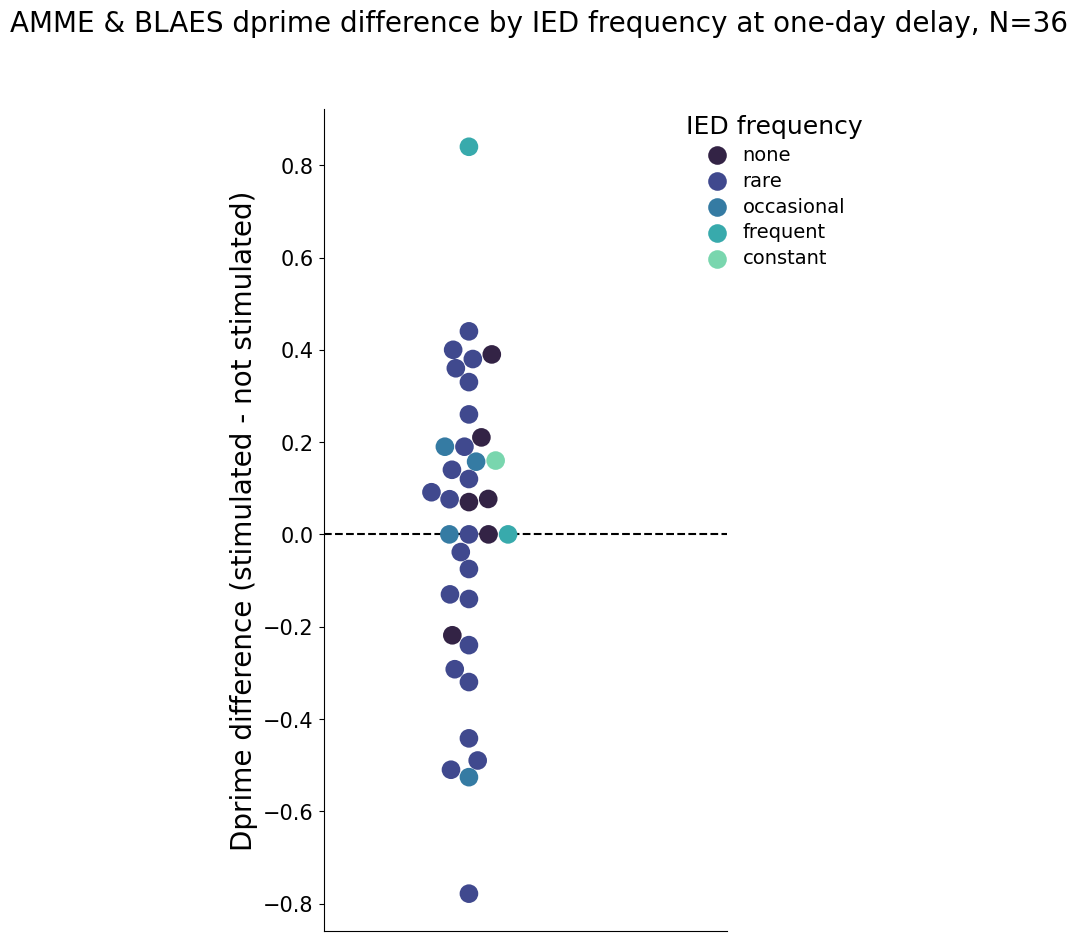

In [10]:
# Clean column
df['IED_freq'] = pd.to_numeric(df['IED_freq'], errors='coerce')

# Keep only valid rows
plot_df = df[
    df['IED_freq'].isin([0, 1, 2, 3, 4]) &
    df['avg_stim_dprime_diff'].notna()
].copy()

# Make x categorical so the swarm sits in one centered column
plot_df['delay_group'] = 'One-day delay'

# Frequency labels
freq_map = {
    0: 'none',
    1: 'rare',
    2: 'occasional',
    3: 'frequent',
    4: 'constant'
}

# Create label column for legend/hue
plot_df['IED_freq_label'] = plot_df['IED_freq'].map(freq_map)

# Order
hue_order = ['none', 'rare', 'occasional', 'frequent', 'constant']

# Palette
colors = sns.color_palette("mako", 5)
palette = dict(zip(hue_order, colors))

print("Rows to plot:", len(plot_df))
print(plot_df[['IED_freq', 'IED_freq_label', 'avg_stim_dprime_diff']].head(20))
print(plot_df['IED_freq_label'].value_counts(dropna=False))

# Create swarm plot
ax1 = sns.catplot(
    x="delay_group",
    y="avg_stim_dprime_diff",
    hue="IED_freq_label",
    hue_order=hue_order,
    data=plot_df,
    kind="swarm",
    s=180,
    palette=palette,
    height=10,
    aspect=0.55
)

ax = ax1.ax

# Remove top/right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Horizontal reference line at 0
ax.axhline(0, linestyle='--', color='black', linewidth=1.5, zorder=0)

# Labels and title
ax.set_ylabel("Dprime difference (stimulated - not stimulated)", fontsize=20)
ax.set_xlabel("")
ax.set_title("")

ax1.fig.suptitle(
    "AMME & BLAES dprime difference by IED frequency at one-day delay, N={}".format(len(plot_df)),
    fontsize=20
)

# Remove x tick label
ax.set_xticks([])

# Match your previous single-column swarm layout
ax.set_xlim(-0.18, 0.32)

# Tick formatting
ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', length=0)

# Adjust layout
ax1.fig.subplots_adjust(left=0.18, right=0.78, top=0.88)

# Legend styling
leg = ax1._legend
leg.set_bbox_to_anchor((1.3, 0.75))
leg.set_frame_on(False)

for text in leg.get_texts():
    text.set_fontsize(14)

leg.set_title("IED frequency", prop={'size': 18})

# Save and show
plt.savefig('AMMEBLAES_IED_frequency_swarmplot.png', dpi=300, bbox_inches='tight')
plt.show()

### Plot Memory measures